,image_path,h11,h12,h13,h21,h22,h23,h31,h32
0,peper/input_images\1.png,1.550024,0.085322,-76.249814,-0.200061,2.200670,-118.436065,-0.000760,0.001391
1,peper/input_images\1frame_0000.png,1.756865,0.111463,-288.996300,0.079723,2.642253,-698.784706,0.000056,0.000388
2,peper/input_images\1frame_0001.jpg,1.782410,0.115527,-295.913089,0.046910,2.685599,-753.539157,0.000049,0.000381
3,peper/input_images\1frame_0002.jpg,1.702126,0.072652,-254.426312,0.032984,2.484775,-556.237677,0.000002,0.000310
4,peper/input_images\1frame_0003.jpg,1.784545,0.088949,-279.211813,0.046527,2.558977,-646.444046,0.000023,0.000314


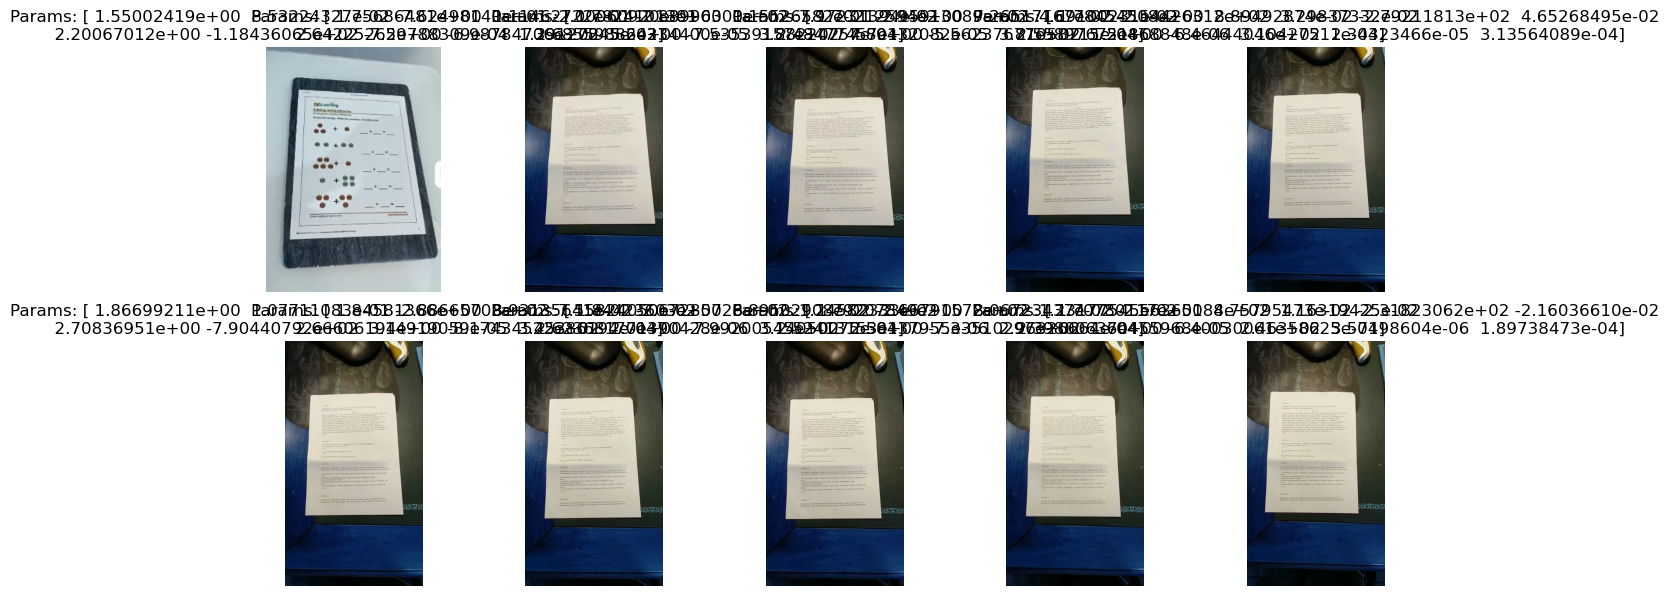

Epoch: 1, Train Loss: 183320.51416015625
Epoch: 2, Train Loss: 133466.46142578125
Epoch: 3, Train Loss: 86321.72021484375
Epoch: 4, Train Loss: 70579.02850341797
Epoch: 5, Train Loss: 58218.88391113281
Epoch: 6, Train Loss: 46163.613525390625
Epoch: 7, Train Loss: 44959.81823730469
Epoch: 8, Train Loss: 35235.26077270508
Epoch: 9, Train Loss: 34436.43035888672
Epoch: 10, Train Loss: 30919.06756591797
Epoch: 11, Train Loss: 23528.513610839844
Epoch: 12, Train Loss: 21338.244659423828
Epoch: 13, Train Loss: 22649.23126220703
Epoch: 14, Train Loss: 18001.984405517578
Epoch: 15, Train Loss: 14217.679565429688
Test Loss: 16942.33056640625


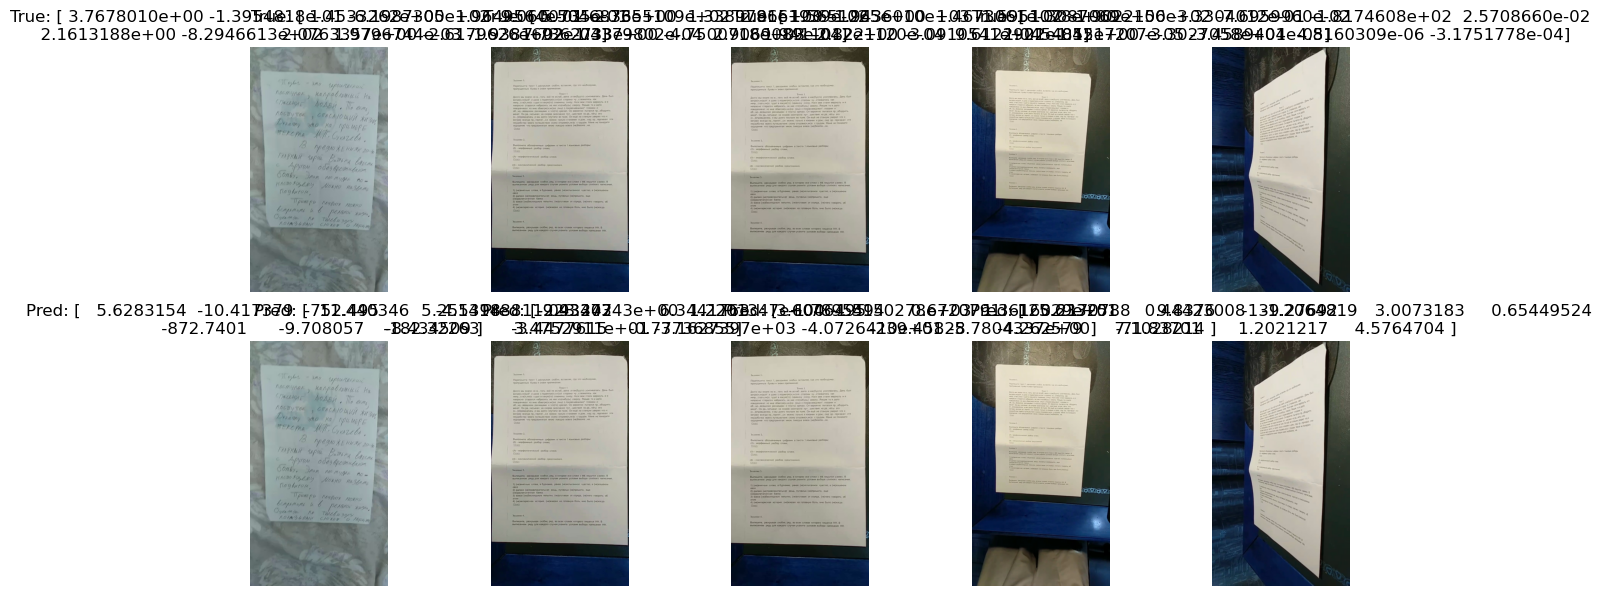

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
from torchvision import transforms
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

# Пути к данным
PATH = 'peper/'
TRAIN_PATH = PATH +'homography_data.csv'
TEST_PATH = PATH + 'test_data.csv'  # Если у вас есть тестовые данные

# Загрузка данных
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH) if os.path.exists(TEST_PATH) else None

display(train_df.head())
if test_df is not None:
    display(test_df.head())

# Преобразование данных
train_images = [cv2.imread(img_path) for img_path in train_df['image_path']]
train_labels = train_df.iloc[:, 1:].values  # Параметры гомографии

if test_df is not None:
    test_images = [cv2.imread(img_path) for img_path in test_df['image_path']]
    test_labels = test_df.iloc[:, 1:].values

# Функция для отображения изображений
def display_images(images, labels, rows=2, cols=5):
    fig = plt.figure(figsize=(15, 7))
    for index in range(rows * cols):
        ax = fig.add_subplot(rows, cols, index + 1)
        ax.imshow(images[index])
        ax.set_title(f"Params: {labels[index]}")
        ax.axis('off')
    plt.show()

display_images(train_images, train_labels)

# Разделение данных на обучающую и тестовую выборки
train_images, test_images, train_labels, test_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=101
)

# Класс для создания датасета
class CreateDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        inp = self.X[idx].astype(np.float32)
        out = self.y[idx].astype(np.float32)

        if self.transform:
            inp = self.transform(inp)

        return inp, out

# Преобразования для изображений
t = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Создание датасетов и загрузчиков
train_dataset = CreateDataset(train_images, train_labels, transform=t)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=32)

test_dataset = CreateDataset(test_images, test_labels, transform=t)
test_loader = DataLoader(test_dataset, shuffle=True, batch_size=32)

# Архитектура модели
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(64 * 62 * 62, 512)
        self.fc2 = nn.Linear(512, 8)  # 8 параметров гомографии

    def forward(self, x):
        x = self.relu(self.pool(self.conv1(x)))
        x = self.relu(self.pool(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Обучение модели
EPOCHS = 15
net = Net()
criterion = nn.MSELoss()  # Среднеквадратичная ошибка для регрессии
optimizer = Adam(net.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    net.train()
    running_loss = 0.0
    for data in train_loader:
        X_train, y_train = data
        optimizer.zero_grad()
        y_pred = net(X_train)
        train_loss = criterion(y_pred, y_train)
        train_loss.backward()
        optimizer.step()
        running_loss += train_loss.item()
    print(f"Epoch: {epoch + 1}, Train Loss: {running_loss / len(train_loader)}")

# Тестирование модели
net.eval()
test_loss = 0.0
pred_y = []
test_y = []

for data in test_loader:
    X_test, y_test = data
    with torch.no_grad():
        output = net(X_test)
        test_loss += criterion(output, y_test).item()
        pred_y.append(output.numpy())
        test_y.append(y_test.numpy())

print(f"Test Loss: {test_loss / len(test_loader)}")

# Преобразование результатов
pred_y = np.concatenate(pred_y)
test_y = np.concatenate(test_y)

# Визуализация результатов
def display_results(pred_y, test_y):
    fig = plt.figure(figsize=(15, 7))
    for i in range(5):
        ax = fig.add_subplot(2, 5, i + 1)
        ax.imshow(test_images[i])
        ax.set_title(f"True: {test_y[i]}")
        ax.axis('off')

        ax = fig.add_subplot(2, 5, i + 6)
        ax.imshow(test_images[i])
        ax.set_title(f"Pred: {pred_y[i]}")
        ax.axis('off')
    plt.show()

display_results(pred_y, test_y)